**1.Kiểm tra data dữ liệu lịch sử giao dịch của user**

In [1]:
import pandas as pd

file_path = "transactions_train.csv"
df_head = pd.read_csv(file_path, nrows=5)
display(df_head)

print("\n Data type")
print(df_head.dtypes)

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2



 Data type
t_dat                object
customer_id          object
article_id            int64
price               float64
sales_channel_id      int64
dtype: object


customer_id là một chuỗi siêu dài (type object) -> ngốn RAM

articel_id đang ở dạng int64 -> bị mất số 0 ở đầu

Sales_channel_id có 2 giá trị:

2 - mua online


1 - mua offline

**2. Phân tích hành vi & ước tính RAM**

In [2]:
import pandas as pd
import gc

file_path = "transactions_train.csv"

print("1. Load danh sách Article ID hợp lệ từ csv")
df_valid = pd.read_csv("dataset_final_qwen_filled.csv", usecols=["article_id"], dtype={"article_id": str})
valid_ids = set(df_valid["article_id"].str.zfill(10))
del df_valid
gc.collect()

print("2. Load toàn bộ file transactions_train.csv...")
df_trans = pd.read_csv(
    file_path, 
    usecols=["t_dat", "customer_id", "article_id"], 
    dtype={"article_id": str}
)
# Tiền xử lý chuẩn chỉ
df_trans["article_id"] = df_trans["article_id"].str.zfill(10)
df_trans['t_dat'] = pd.to_datetime(df_trans['t_dat']) # Đã bổ sung ép kiểu thời gian

total_rows_original = len(df_trans)
print(f"\n=> Tổng số dòng dữ liệu gốc thực tế: {total_rows_original:,}")

print("3. Lọc dữ liệu giao dịch theo tập 70k...")
df_trans = df_trans[df_trans["article_id"].isin(valid_ids)]
total_rows_filtered = len(df_trans)
print(f"=> Tổng số dòng sau khi lọc: {total_rows_filtered:,} (Độ phủ: {total_rows_filtered/total_rows_original*100:.2f}%)")

print("\n4. Phân tích giỏ hàng trên TOÀN TẬP dữ liệu hợp lệ...")
# Loại bỏ các giao dịch trùng lặp (cùng user, cùng ngày, mua cùng 1 mã article)
df_trans = df_trans.drop_duplicates(subset=['customer_id', 't_dat', 'article_id'])
basket_sizes = df_trans.groupby(['customer_id', 't_dat']).size()

total_baskets = len(basket_sizes)
baskets_size_1 = (basket_sizes == 1).sum()
baskets_size_gt_1 = (basket_sizes > 1).sum()

print(f"\n- Tổng số giỏ hàng (Baskets) thực tế: {total_baskets:,}")
print(f"- Giỏ hàng 1 món (Rác đối với Graph): {baskets_size_1:,} ({baskets_size_1/total_baskets*100:.2f}%)")
print(f"- Giỏ hàng > 1 món (Hợp lệ để tạo Graph): {baskets_size_gt_1:,} ({baskets_size_gt_1/total_baskets*100:.2f}%)")

print("\n5. Thống kê phân phối trên các giỏ hàng HỢP LỆ (> 1 món):")
valid_baskets = basket_sizes[basket_sizes > 1]
print(valid_baskets.describe())

1. Load danh sách Article ID hợp lệ từ csv
2. Load toàn bộ file transactions_train.csv...

=> Tổng số dòng dữ liệu gốc thực tế: 31,788,324
3. Lọc dữ liệu giao dịch theo tập 70k...
=> Tổng số dòng sau khi lọc: 30,282,207 (Độ phủ: 95.26%)

4. Phân tích giỏ hàng trên TOÀN TẬP dữ liệu hợp lệ...

- Tổng số giỏ hàng (Baskets) thực tế: 8,832,987
- Giỏ hàng 1 món (Rác đối với Graph): 2,957,957 (33.49%)
- Giỏ hàng > 1 món (Hợp lệ để tạo Graph): 5,875,030 (66.51%)

5. Thống kê phân phối trên các giỏ hàng HỢP LỆ (> 1 món):
count    5.875030e+06
mean     4.129526e+00
std      3.088632e+00
min      2.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      1.180000e+02
dtype: float64


Ta đang có 30M triệu dòng lịch sử giao dịch và ta đang có 5M dòng có vẻ khả thi để tạo graph vì chúng có trên 5M giao dịch

Với cái giỏ hàng trên 1 món, ta có min 2 và max 118. Có vẻ 118 là các shop mua sỉ

**Kiểm tra data xem, các món được mua chung có hình dạng ra sao, có hợp nhau không -> Lôi top 20 cặp sp được mua chung nhiều nhất ra ghép với metadata gốc**

In [3]:
from collections import Counter
import itertools
import gc

# Giả định df_trans đã được nạp và clean từ Cell 2
print("1. Tạo giỏ hàng từ df_trans...")
baskets = df_trans.groupby(['customer_id', 't_dat'])['article_id'].apply(list).reset_index()

baskets['size'] = baskets['article_id'].apply(len)
baskets = baskets[(baskets['size'] > 1) & (baskets['size'] <= 10)]

print("2. Đếm các cặp mua chung...")
pair_counter = Counter()
for items in baskets['article_id']:
    items = sorted(items)
    for pair in itertools.combinations(items, 2):
        pair_counter[pair] += 1

del baskets
gc.collect()

print("3. Lọc nhiễu và tạo Dataframe tổng...")
# Lấy TẤT CẢ các cặp xuất hiện từ 5 lần trở lên
all_valid_pairs = [(k[0], k[1], v) for k, v in pair_counter.items() if v >= 5]
df_all_pairs = pd.DataFrame(all_valid_pairs, columns=['Item_A', 'Item_B', 'Count'])

# Sắp xếp giảm dần theo tần suất
df_all_pairs = df_all_pairs.sort_values(by='Count', ascending=False).reset_index(drop=True)
print(f"-> Phát hiện {len(df_all_pairs):,} cặp sản phẩm hợp lệ.")

print("4. Ghép nối Metadata (để hiển thị text khi soi ảnh)...")
df_meta = pd.read_csv("dataset_final_qwen_filled.csv", 
                      usecols=['article_id', 'product_type_name', 'department_name', 'colour_group_name'],
                      dtype={'article_id': str})
df_meta['article_id'] = df_meta['article_id'].str.zfill(10)

df_all_pairs = df_all_pairs.merge(df_meta, left_on='Item_A', right_on='article_id', how='left').rename(columns={'product_type_name': 'Type_A', 'department_name': 'Dept_A', 'colour_group_name': 'Color_A'}).drop('article_id', axis=1)
df_all_pairs = df_all_pairs.merge(df_meta, left_on='Item_B', right_on='article_id', how='left').rename(columns={'product_type_name': 'Type_B', 'department_name': 'Dept_B', 'colour_group_name': 'Color_B'}).drop('article_id', axis=1)

print("Hoàn tất Cell 3! Sẵn sàng duyệt ảnh.")

1. Tạo giỏ hàng từ df_trans...
2. Đếm các cặp mua chung...
3. Lọc nhiễu và tạo Dataframe tổng...
-> Phát hiện 792,925 cặp sản phẩm hợp lệ.
4. Ghép nối Metadata (để hiển thị text khi soi ảnh)...
Hoàn tất Cell 3! Sẵn sàng duyệt ảnh.


Display ra xem thử có hợp nhau thật không

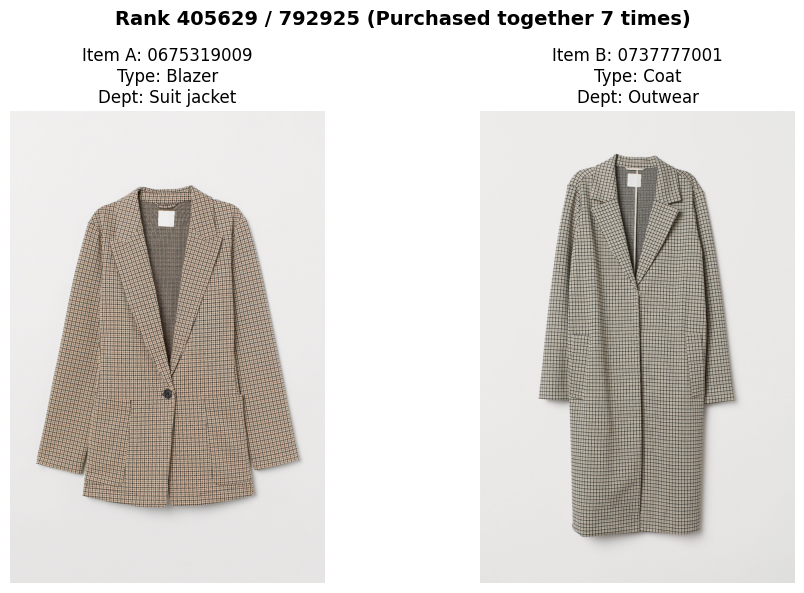

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Hàm lấy đường dẫn ảnh
def get_image_path(article_id):
    article_id_str = str(article_id).zfill(10)
    folder = article_id_str[:3]
    return os.path.join("images", folder, f"{article_id_str}.jpg")

# ==========================================
# GÕ RANK CẦN KIỂM TRA VÀO ĐÂY (0 đến len(df_all_pairs)-1)
# Hoặc để check = "random" để rút ngẫu nhiên
check = "random" 
# ==========================================

total_pairs = len(df_all_pairs)
if check == "random":
    idx = random.randint(0, total_pairs - 1)
elif isinstance(check, int) and 0 <= check < total_pairs:
    idx = check
else:
    raise ValueError(f"Biến check phải là 'random' hoặc số nguyên từ 0 đến {total_pairs - 1}")

row = df_all_pairs.iloc[idx]
item_A_id, item_B_id, count = row['Item_A'], row['Item_B'], row['Count']
img_path_A, img_path_B = get_image_path(item_A_id), get_image_path(item_B_id)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Xử lý hình A
if os.path.exists(img_path_A):
    axes[0].imshow(Image.open(img_path_A))
else:
    axes[0].text(0.5, 0.5, 'Image Not Found', ha='center')
axes[0].set_title(f"Item A: {item_A_id}\nType: {row['Type_A']}\nDept: {row['Dept_A']}")
axes[0].axis('off')

# Xử lý hình B
if os.path.exists(img_path_B):
    axes[1].imshow(Image.open(img_path_B))
else:
    axes[1].text(0.5, 0.5, 'Image Not Found', ha='center')
axes[1].set_title(f"Item B: {item_B_id}\nType: {row['Type_B']}\nDept: {row['Dept_B']}")
axes[1].axis('off')

plt.suptitle(f"Rank {idx + 1} / {total_pairs} (Purchased together {count} times)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Về cơ bản, các món đồ mua chung nhau khá hợp. Kiểm tra xem các món mua 3 cùng lúc sẽ ra sao

In [5]:
from collections import Counter
import itertools
import gc
import pandas as pd

print("1. Đang tạo giỏ hàng (chỉ lấy giỏ từ 3 đến 10 món)...")
baskets_3 = df_trans.groupby(['customer_id', 't_dat'])['article_id'].apply(list).reset_index()
baskets_3['size'] = baskets_3['article_id'].apply(len)
baskets_3 = baskets_3[(baskets_3['size'] >= 3) & (baskets_3['size'] <= 10)]

print("2. Đang đếm tổ hợp 3 món (Triplets)...")
triplet_counter = Counter()
for items in baskets_3['article_id']:
    items = sorted(items)
    for triplet in itertools.combinations(items, 3):
        triplet_counter[triplet] += 1

del baskets_3
gc.collect()

print("3. Đang lọc nhiễu và ghép Metadata...")
# Lọc lấy các tổ hợp xuất hiện từ 3 lần trở lên
valid_triplets = [(k[0], k[1], k[2], v) for k, v in triplet_counter.items() if v >= 3]
df_triplets = pd.DataFrame(valid_triplets, columns=['Item_A', 'Item_B', 'Item_C', 'Count'])
df_triplets = df_triplets.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Đọc file 70k để lấy metadata
df_meta = pd.read_csv("dataset_final_qwen_filled.csv", 
                      usecols=['article_id', 'product_type_name', 'department_name', 'colour_group_name'],
                      dtype={'article_id': str})
df_meta['article_id'] = df_meta['article_id'].str.zfill(10)

# Merge metadata cho Item A, B, C
for col, prefix in zip(['Item_A', 'Item_B', 'Item_C'], ['A', 'B', 'C']):
    df_triplets = df_triplets.merge(df_meta, left_on=col, right_on='article_id', how='left')
    df_triplets = df_triplets.rename(columns={
        'product_type_name': f'Type_{prefix}', 
        'department_name': f'Dept_{prefix}', 
        'colour_group_name': f'Color_{prefix}'
    }).drop('article_id', axis=1)

print(f"-> Xử lý xong! Đã lưu {len(df_triplets):,} bộ 3 hợp lệ vào biến df_triplets.")

1. Đang tạo giỏ hàng (chỉ lấy giỏ từ 3 đến 10 món)...


2. Đang đếm tổ hợp 3 món (Triplets)...
3. Đang lọc nhiễu và ghép Metadata...
-> Xử lý xong! Đã lưu 304,505 bộ 3 hợp lệ vào biến df_triplets.


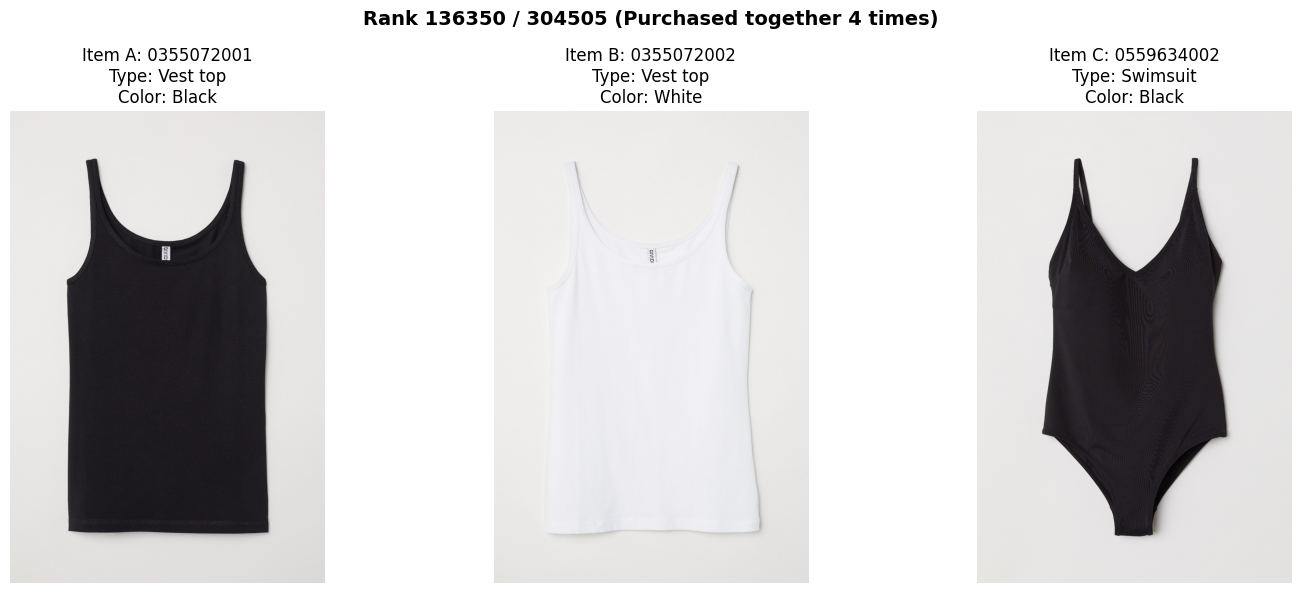

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

def get_image_path(article_id):
    article_id_str = str(article_id).zfill(10)
    folder = article_id_str[:3]
    return os.path.join("images", folder, f"{article_id_str}.jpg")

# ==========================================
# ĐIỀN THỨ HẠNG HOẶC "random" VÀO ĐÂY
check = "random" 
# ==========================================

total_triplets = len(df_triplets)
if check == "random":
    idx = random.randint(0, total_triplets - 1)
elif isinstance(check, int) and 0 <= check < total_triplets:
    idx = check
else:
    raise ValueError(f"Biến check phải là 'random' hoặc số nguyên từ 0 đến {total_triplets - 1}")

row = df_triplets.iloc[idx]
count = row['Count']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, prefix in enumerate(['A', 'B', 'C']):
    item_id = row[f'Item_{prefix}']
    img_path = get_image_path(item_id)
    
    if os.path.exists(img_path):
        axes[i].imshow(Image.open(img_path))
    else:
        axes[i].text(0.5, 0.5, 'Image Not Found', ha='center', va='center')
        
    axes[i].set_title(f"Item {prefix}: {item_id}\nType: {row[f'Type_{prefix}']}\nColor: {row[f'Color_{prefix}']}")
    axes[i].axis('off')

plt.suptitle(f"Rank {idx + 1} / {total_triplets} (Purchased together {count} times)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

-> Tức là user không có thói quen lúc nào cũng mua một outfit 3 món như kiểu áo+quần+giày 

-> khả năng là mua 2 bộ riêng biệt, kiểm tra thử xem

Kiểm tra 4 món

In [7]:
from collections import Counter
import itertools
import gc
import pandas as pd

print("1. Đang tạo giỏ hàng (chỉ lấy giỏ từ 4 đến 10 món)...")
baskets_4 = df_trans.groupby(['customer_id', 't_dat'])['article_id'].apply(list).reset_index()
baskets_4['size'] = baskets_4['article_id'].apply(len)
baskets_4 = baskets_4[(baskets_4['size'] >= 4) & (baskets_4['size'] <= 10)]

print("2. Đang đếm tổ hợp 4 món (Quadruplets)...")
quad_counter = Counter()
for items in baskets_4['article_id']:
    items = sorted(items)
    for quad in itertools.combinations(items, 4):
        quad_counter[quad] += 1

del baskets_4
gc.collect()

print("3. Đang lọc nhiễu và ghép Metadata...")
# Lấy các tổ hợp xuất hiện từ 2 lần trở lên (tổ hợp 4 rất hiếm)
valid_quads = [(k[0], k[1], k[2], k[3], v) for k, v in quad_counter.items() if v >= 2]
df_quads = pd.DataFrame(valid_quads, columns=['Item_A', 'Item_B', 'Item_C', 'Item_D', 'Count'])
df_quads = df_quads.sort_values(by='Count', ascending=False).reset_index(drop=True)

df_meta = pd.read_csv("dataset_final_qwen_filled.csv", 
                      usecols=['article_id', 'product_type_name', 'department_name', 'colour_group_name'],
                      dtype={'article_id': str})
df_meta['article_id'] = df_meta['article_id'].str.zfill(10)

for col, prefix in zip(['Item_A', 'Item_B', 'Item_C', 'Item_D'], ['A', 'B', 'C', 'D']):
    df_quads = df_quads.merge(df_meta, left_on=col, right_on='article_id', how='left')
    df_quads = df_quads.rename(columns={
        'product_type_name': f'Type_{prefix}', 
        'department_name': f'Dept_{prefix}', 
        'colour_group_name': f'Color_{prefix}'
    }).drop('article_id', axis=1)

print(f"-> Xử lý xong! Đã lưu {len(df_quads):,} bộ 4 hợp lệ vào biến df_quads.")

1. Đang tạo giỏ hàng (chỉ lấy giỏ từ 4 đến 10 món)...
2. Đang đếm tổ hợp 4 món (Quadruplets)...
3. Đang lọc nhiễu và ghép Metadata...
-> Xử lý xong! Đã lưu 266,271 bộ 4 hợp lệ vào biến df_quads.


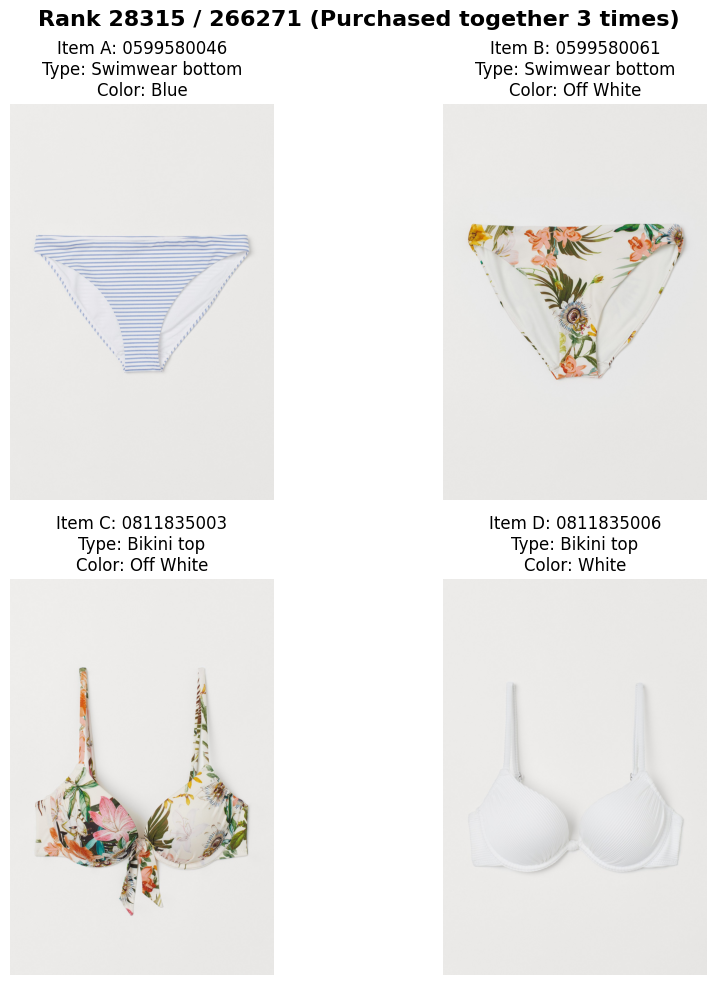

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

def get_image_path(article_id):
    article_id_str = str(article_id).zfill(10)
    folder = article_id_str[:3]
    return os.path.join("images", folder, f"{article_id_str}.jpg")

# ==========================================
# GÕ RANK HOẶC "random" VÀO ĐÂY
check = "random" 
# ==========================================

total_quads = len(df_quads)
if check == "random":
    idx = random.randint(0, total_quads - 1)
elif isinstance(check, int) and 0 <= check < total_quads:
    idx = check
else:
    raise ValueError(f"Biến check phải là 'random' hoặc số nguyên từ 0 đến {total_quads - 1}")

row = df_quads.iloc[idx]
count = row['Count']

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, prefix in enumerate(['A', 'B', 'C', 'D']):
    item_id = row[f'Item_{prefix}']
    img_path = get_image_path(item_id)
    
    
    if os.path.exists(img_path):
        axes[i].imshow(Image.open(img_path))
    else:
        axes[i].text(0.5, 0.5, 'Image Not Found', ha='center', va='center')
        
    axes[i].set_title(f"Item {prefix}: {item_id}\nType: {row[f'Type_{prefix}']}\nColor: {row[f'Color_{prefix}']}")
    axes[i].axis('off')

plt.suptitle(f"Rank {idx + 1} / {total_quads} (Purchased together {count} times)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()